# 02. Exploratory Data Analysis (EDA)
**Objective:** Explore the data to understand the target variable, find data issues, and identify key patterns related to loan default.

## 1. Load Data
Load the dataset and convert numbers stored as text (containing symbols like `$`, `x`, `&`) into standard numeric values.

In [6]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress minor warnings for clean presentation
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load data
data_path = 'data/raw/Train_Dataset.csv' if os.path.exists('data/raw/Train_Dataset.csv') else '../data/raw/Train_Dataset.csv'
df = pd.read_csv(data_path, low_memory=False)

# Convert columns with dirty strings to numeric (coercing symbols to NaN)
num_cols = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Employed_Days', 
    'Score_Source_1', 'Score_Source_2', 'Score_Source_3', 'Age_Days', 
    'Registration_Days', 'ID_Days', 'Phone_Change', 'Cleint_City_Rating', 'Child_Count'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Dataset loaded:", df.shape[0], "rows and", df.shape[1], "columns.")

Dataset loaded: 121856 rows and 40 columns.


## 2. Target Distribution (`Default`)
Check the proportion of customers who repaid (`0`) versus those who defaulted (`1`).

Class counts:
Default
0    112011
1      9845
Name: count, dtype: int64

Class percentages:
Default
0    91.92
1     8.08
Name: proportion, dtype: float64


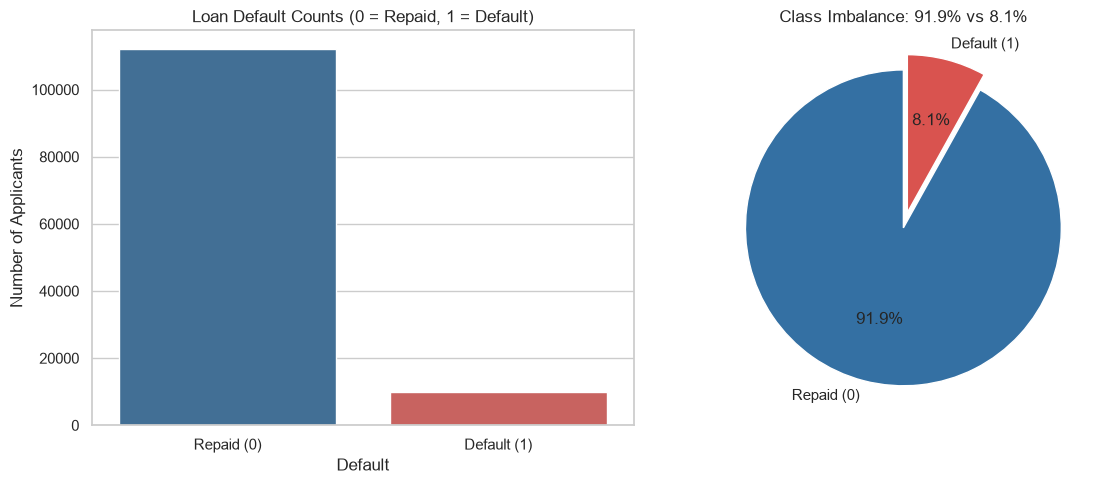

In [7]:
# Display class frequencies
print("Class counts:")
print(df['Default'].value_counts())
print("\nClass percentages:")
print((df['Default'].value_counts(normalize=True) * 100).round(2))

# Plot countplot and pie chart side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Countplot
sns.countplot(x='Default', hue='Default', data=df, palette=['#3470a3', '#d9534f'], legend=False, ax=axes[0])
axes[0].set_title('Loan Default Counts (0 = Repaid, 1 = Default)')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Repaid (0)', 'Default (1)'])

# 2. Pie chart
df['Default'].value_counts().plot.pie(
    autopct='%.1f%%', 
    labels=['Repaid (0)', 'Default (1)'], 
    colors=['#3470a3', '#d9534f'],
    explode=[0, 0.1],
    startangle=90,
    ax=axes[1]
)
axes[1].set_title('Class Imbalance: 91.9% vs 8.1%')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Key Takeaways:
- **Class Imbalance:** 91.9% repaid their loans, while only 8.1% defaulted.
- **Accuracy is Misleading:** A model that predicts "repaid" for everyone gets 91.9% accuracy, but catches zero defaulters.
- **What to Use:** We need metrics like **Precision, Recall, and F1-score** rather than simple accuracy.